In [12]:
import sys
import os
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import pickle
from scipy.optimize import linprog
from main import OU_w_derivative
# =======================

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# get the parent directory (the folder that contains notebooks/ and scripts/)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# add to PYTHONPATH
sys.path.append(os.path.join(parent_dir,"scripts"))
sys.path



['/Users/taung/Desktop/CAISO_exps/BO+ShadowGP_diagnosis/auto',
 '/Users/taung/miniconda3/envs/energy_mike/lib/python310.zip',
 '/Users/taung/miniconda3/envs/energy_mike/lib/python3.10',
 '/Users/taung/miniconda3/envs/energy_mike/lib/python3.10/lib-dynload',
 '',
 '/Users/taung/miniconda3/envs/energy_mike/lib/python3.10/site-packages',
 '/Users/taung/Desktop/CAISO_exps/BO+ShadowGP_diagnosis/scripts',
 '/Users/taung/Desktop/CAISO_exps/BO+ShadowGP_diagnosis/scripts',
 '/Users/taung/Desktop/CAISO_exps/BO+ShadowGP_diagnosis/scripts',
 '/Users/taung/Desktop/CAISO_exps/BO+ShadowGP_diagnosis/scripts']

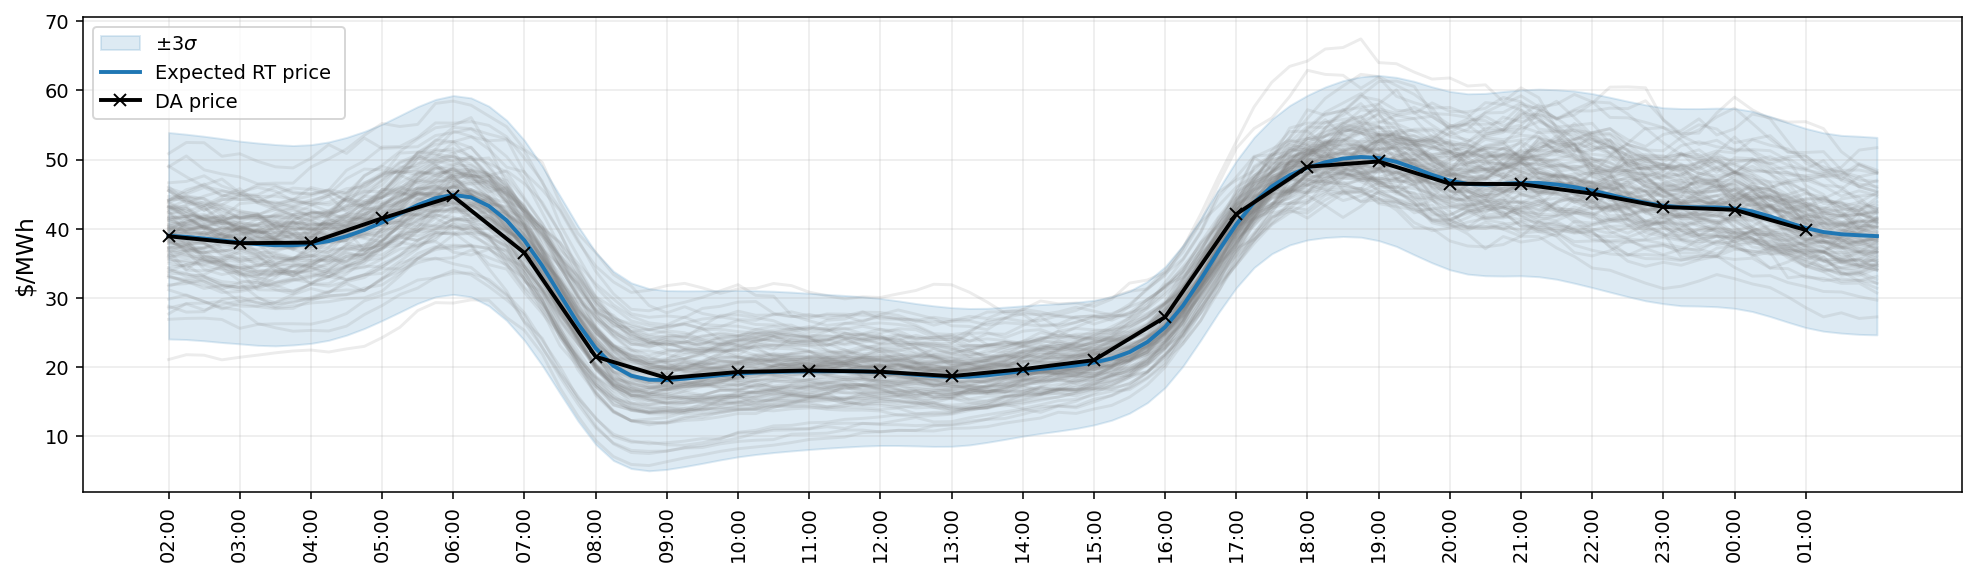

In [15]:

ou_alpha = 0.1
sigma = 0.05
ou_seed = 1234
sigma0 = 5
nstep = 96
nsim = 10000
maturity = 24
with open('cubic_spline.pkl','rb') as f:
    saved_spline_spline_der = pickle.load(f)

np.random.seed(1234)

period = 24.0
def M_func(t):  return saved_spline_spline_der['cs'](t)
def dM_func(t): return saved_spline_spline_der['csd'](t)


X0 = np.random.normal(M_func(0), sigma0, size=nsim)
process2 = OU_w_derivative(
    X0=X0,
    nstep=nstep,
    nsim=nsim,
    maturity=maturity,
    alpha=ou_alpha,
    meanRevRate_func=M_func,
    dmeanRevRate_func=dM_func,
    sigma=sigma,
    noises=None,
    seed=ou_seed,
)

multiplier = 1
rt_paths = multiplier * process2.sim_trajectories
mean_path = np.mean(rt_paths, axis=0)
std_path = np.std(rt_paths, axis=0)
UB, LB = mean_path + 3 * std_path, mean_path - 3 * std_path

hours = np.arange(24)
hour_idx = np.arange(0, nstep, 4)
DA_lmp = np.asarray(M_func(hours), dtype=float)
hour_labels = [(h + 2) % 24 for h in hours]

fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
for i in range(100):
    ax.plot(process2.t, rt_paths[i, :], color="gray", alpha=0.15)
ax.fill_between(process2.t, LB, UB, color="tab:blue", alpha=0.15, label=r"$\pm 3\sigma$")
ax.plot(process2.t, mean_path, color="tab:blue", linewidth=2, label=r"Expected RT price ")
ax.plot(process2.t[hour_idx], DA_lmp, marker="x", linewidth=2, color="black", label=r"DA price ")
ax.set_ylabel("$/MWh",size=12)
ax.set_xticks(process2.t[hour_idx])
ax.set_xticklabels([f"{h:02d}:00" for h in hour_labels], rotation=90)
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


In [14]:
process2.sim_trajectories.shape

(10000, 97)